In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Problem 10.2-72 &mdash; does ethyl acetate / benzene have an azeotrope?

The problem asks you to estimate the vapor-liquid equilibrium of ethyl acetate / benzene at
1 bar with the **UNIFAC** model, and then to say whether the system has an azeotrope. It is
a one-line question with a genuinely interesting answer, because the *other* model available
for this pair says the opposite.

Two routes to the same mixture, and they disagree:

- **Table 9.5-1** tabulates van Laar constants for ethyl acetate / benzene, fitted to data.
  They give a strongly nonideal mixture, and an azeotrope.
- **UNIFAC** predicts activity coefficients from **molecular structure alone**, with no
  mixture data of any kind.

Both are computed below, at 1 bar as the problem asks and at a fixed temperature as well, so
the disagreement can be seen from both sides. Deciding between them is the point of the
exercise: an azeotrope is not a model output to be accepted, it is a claim about a real
mixture that can be checked against a reference compilation.

**This is why Section 10.2's worked example is methyl acetate / methanol and not this
pair.** The 5e built Illustrations 10.2-2 and 10.2-3 and a two-column distillation design on
the van Laar answer below. Standard azeotrope compilations do not list an ethyl acetate /
benzene azeotrope, and the 5e's own bracketed Aspen note concedes that *"the van Laar model
is not a good one for this system"* &mdash; so in the 6e the worked example moved to a real
azeotrope and the model-limits lesson became this problem, where you do the disproving.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from thermo import UNIFAC
from thermo.vle import Antoine, GammaPhi, pxy, txy, azeotrope
from thermo.vle_chart import pxy_chart, txy_chart, xy_chart, mark_azeotrope
from thermo.activity_models import VanLaar, TABLE_9_5_1_VAN_LAAR
from thermo.charts import use_book_style
use_book_style()

# Antoine constants as the 5e's Illustration 10.2-2 printed them for this pair; note C
# is negated because the book writes the denominator as T - 56.3209 and `Antoine` is
# defined with T + C. The vapor pressures are not in dispute here -- both models below
# use these same two curves, so any difference between them is liquid nonideality alone.
EA = Antoine(9.6830, 2842.2, -56.3209)      # ethyl acetate
BZ = Antoine(9.3171, 2810.5, -51.2586)      # benzene
alpha, beta, rng = TABLE_9_5_1_VAN_LAAR["ethyl acetate-benzene"]
print(f"van Laar constants from Table 9.5-1: alpha = {alpha}, beta = {beta}"
      f"   (valid over {rng} C)")

mix = GammaPhi([EA, BZ], VanLaar(alpha, beta), names=["ethyl acetate", "benzene"])
T_a = 273.15 + 75.0
print(f"Pvap at 75 C:  ethyl acetate {EA.P(T_a)/1e5:.3f} bar, benzene {BZ.P(T_a)/1e5:.3f} bar")
print(f"normal boiling points: ethyl acetate {EA.T_sat(1.01325e5)-273.15:.1f} C, "
      f"benzene {BZ.T_sat(1.01325e5)-273.15:.1f} C -- three degrees apart")

van Laar constants from Table 9.5-1: alpha = 1.15, beta = 0.92   (valid over 71.1-80.2 C)
Pvap at 75 C:  ethyl acetate 0.945 bar, benzene 0.861 bar
normal boiling points: ethyl acetate 77.1 C, benzene 80.2 C -- three degrees apart


## Model 1: the tabulated van Laar constants, at 75 °C

At fixed $T$ the bubble pressure is explicit, exactly as in Section 10.1 &mdash; the
activity coefficients depend on composition but not on the pressure being computed. The
only change from an ideal mixture is the $\gamma_i$ factor.

In [3]:
x1, y1, P = pxy(mix, T_a)
az_a = azeotrope(mix, T=T_a)
print(f"azeotrope at 75 C:  x_EA = {az_a[0]:.4f},  P = {az_a[1]/1e5:.4f} bar")
print(f"\npure-component vapor pressures: {EA.P(T_a)/1e5:.4f} and {BZ.P(T_a)/1e5:.4f} bar")
print("a MAXIMUM-pressure azeotrope must lie above both, and this one does.")

azeotrope at 75 C:  x_EA = 0.5181,  P = 1.1654 bar

pure-component vapor pressures: 0.9453 and 0.8613 bar
a MAXIMUM-pressure azeotrope must lie above both, and this one does.


### A footnote on the 5e's printed numbers

The 5e's Illustration 10.2-2 ended part (a) with *"an azeotrope occurs at an ethyl acetate
mole fraction of 0.581 and a pressure of 0.518 bar."* Neither number survives contact with
its own calculation: the same constants give $x_{\rm EA} = 0.518$ and $P = 1.165$ bar, and
**0.581 is 0.518 with two digits transposed, with the composition then written into the
pressure slot.** 0.518 bar is impossible anyway — the text calls it a *maximum* in the
$P$-$x$-$y$ diagram, and a maximum-pressure azeotrope must lie above both pure vapor
pressures, which the same page gives as 0.946 and 0.862 bar. The 5e's own art agreed with
the computation all along: its pressure axis ran 0.85 to 1.15 bar.

Filed as erratum **E14**, and **superseded**: the illustration that printed it is now methyl
acetate / methanol, so there is no longer a printed number to correct. It is kept here
because it is the first sign that this pair was trouble, and because it is a clean example of
the technique — recompute a printed number and let the book disagree with itself.

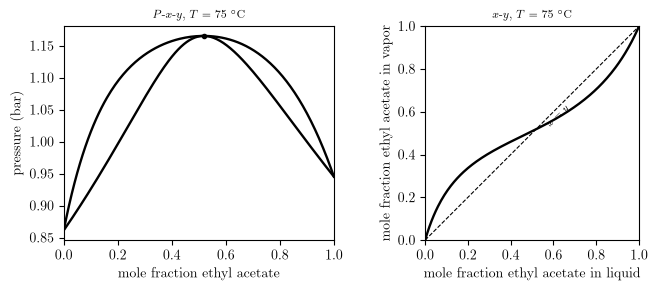

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.9, 3.0))
pxy_chart(a1, x1, y1, P, species="ethyl acetate", regions=False)
mark_azeotrope(a1, az_a[0], az_a[1], text="", offset=(0, 0))
a1.set_title(r"$P$-$x$-$y$, $T$ = 75 $^\circ$C", fontsize=8)
xy_chart(a2, x1, y1, species="ethyl acetate")
a2.set_title(r"$x$-$y$, $T$ = 75 $^\circ$C", fontsize=8)
fig.tight_layout()

The azeotrope is visible twice: as the maximum of the $P$-$x$-$y$ envelope, and as the
point where the $x$-$y$ curve crosses the $x = y$ diagonal. Those are the same statement, and
the crossing is the test to apply below.

Neither envelope carries `Liquid` / `Vapor` region labels. On a maximum-pressure azeotrope
the frame top sits just above the azeotropic point, so the liquid region is a thin band
everywhere and there is no room for them.

## Model 1 at the problem's condition: 1.013 bar

The problem asks about 1 bar, so this is the comparison that matters. Now each composition
needs a temperature solve, because the vapor pressures depend on the unknown. The result is a
**minimum-boiling** azeotrope — the mirror of the maximum-pressure one, and for the same
reason.

In [5]:
P_b = 1.013e5
x1b, y1b, Tb = txy(mix, P_b)
az_b = azeotrope(mix, P=P_b)
print(f"azeotrope at 1.013 bar:  x_EA = {az_b[0]:.4f},  T = {az_b[1]:.2f} K"
      f" = {az_b[1]-273.15:.2f} C")
print(f"largest departure of y from x: {np.nanmax(np.abs(y1b - x1b)):.3f}"
      "   (a crossing of x = y is what an azeotrope IS)")

azeotrope at 1.013 bar:  x_EA = 0.5149,  T = 343.92 K = 70.77 C
largest departure of y from x: 0.139   (a crossing of x = y is what an azeotrope IS)


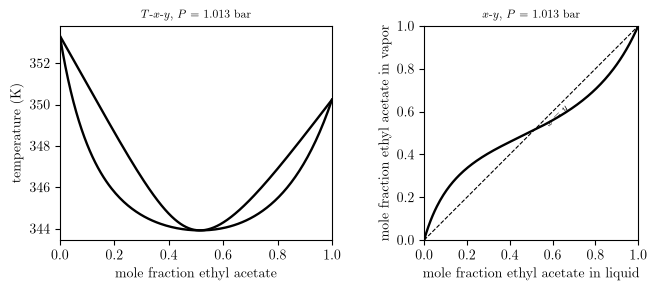

In [6]:
fig, (b1, b2) = plt.subplots(1, 2, figsize=(6.9, 3.0))
txy_chart(b1, x1b, y1b, Tb, species="ethyl acetate", regions=False)
b1.set_title(r"$T$-$x$-$y$, $P$ = 1.013 bar", fontsize=8)
xy_chart(b2, x1b, y1b, species="ethyl acetate")
b2.set_title(r"$x$-$y$, $P$ = 1.013 bar", fontsize=8)
fig.tight_layout()

So on this model the answer to the problem would be *yes, at $x_{\rm EA} = 0.515$ and
70.8 °C* — and that is the answer the 5e's Section 10.2 was built on.

**Why the two diagrams are inverted** is worth noticing on the way past: a mixture with a
higher equilibrium pressure at fixed temperature boils at a lower temperature at fixed
pressure, so a maximum in $P$ becomes a minimum in $T$ at roughly the same composition. The
two azeotropic compositions above, 0.518 and 0.515, are that "roughly".

## Model 2: UNIFAC, which is what the problem asks for

Table 9.5-1 is a compilation — someone fitted those two constants to somebody's data.
UNIFAC predicts activity coefficients from **molecular structure alone**, with no mixture
data of any kind, which is why it can answer a question about a pair nobody measured for you.

Ethyl acetate, CH₃COO–CH₂–CH₃, is one CH₃COO group, one CH₂ and one CH₃. Benzene is six
aromatic CH. That is the entire input.

In [7]:
EA_groups = {21: 1, 2: 1, 1: 1}      # CH3COO + CH2 + CH3
BZ_groups = {9: 6}                    # 6 x ACH
uf = UNIFAC()

# Adapter so UNIFAC satisfies the ActivityModel interface GammaPhi expects.
class UnifacBinary:
    n = 2
    def __init__(self, groups): self.groups = groups
    def gamma(self, x, T): return uf.gamma(self.groups, list(x), T)
    def lngamma(self, x, T): return np.log(self.gamma(x, T))

vl = VanLaar(alpha, beta)
ub = UnifacBinary([EA_groups, BZ_groups])
print("   x_EA    van Laar (Table 9.5-1)      UNIFAC (predicted)")
for x in (0.05, 0.2, 0.5, 0.8, 0.95):
    gv, gu = vl.gamma([x, 1-x], T_a), ub.gamma([x, 1-x], T_a)
    print(f"   {x:.2f}     {gv[0]:.3f} / {gv[1]:.3f}              {gu[0]:.3f} / {gu[1]:.3f}")
print(f"\ninfinite-dilution activity coefficients implied by Table 9.5-1:")
print(f"   ethyl acetate in benzene  exp(alpha) = {np.exp(alpha):.2f}")
print(f"   benzene in ethyl acetate  exp(beta)  = {np.exp(beta):.2f}")

   x_EA    van Laar (Table 9.5-1)      UNIFAC (predicted)
   0.05     2.752 / 1.004              1.071 / 1.000
   0.20     1.950 / 1.054              1.044 / 1.004
   0.50     1.255 / 1.328              1.012 / 1.020
   0.80     1.032 / 1.894              1.001 / 1.040
   0.95     1.002 / 2.333              1.000 / 1.049

infinite-dilution activity coefficients implied by Table 9.5-1:
   ethyl acetate in benzene  exp(alpha) = 3.16
   benzene in ethyl acetate  exp(beta)  = 2.51


UNIFAC at 1.013 bar: NO azeotrope -- x = y is never crossed
   largest departure of y from x: 0.025   (van Laar: 0.139)
   boiling range: 77.1 to 80.2 C, i.e. the two normal boiling points and nothing outside them

UNIFAC at 75 C:   NO azeotrope -- the P-x-y envelope has no interior maximum


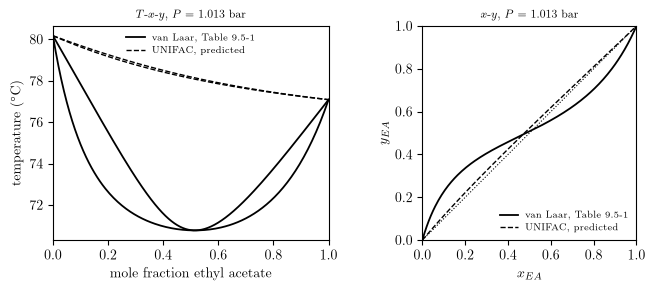

In [8]:
mix_u = GammaPhi([EA, BZ], ub, names=["ethyl acetate", "benzene"])

# The answer to the problem: UNIFAC at 1.013 bar, tested for a crossing of x = y.
xub, yub, Tub = txy(mix_u, P_b)
az_ub = azeotrope(mix_u, P=P_b)
print("UNIFAC at 1.013 bar:",
      f"azeotrope at x_EA = {az_ub[0]:.4f}, T = {az_ub[1]-273.15:.2f} C" if az_ub
      else "NO azeotrope -- x = y is never crossed")
print(f"   largest departure of y from x: {np.nanmax(np.abs(yub - xub)):.3f}"
      f"   (van Laar: {np.nanmax(np.abs(y1b - x1b)):.3f})")
print(f"   boiling range: {Tub.min()-273.15:.1f} to {Tub.max()-273.15:.1f} C,"
      " i.e. the two normal boiling points and nothing outside them")

# and the same question at fixed temperature, for completeness
az_u = azeotrope(mix_u, T=T_a)
print("\nUNIFAC at 75 C:  ",
      f"azeotrope at x_EA = {az_u[0]:.4f}, P = {az_u[1]/1e5:.4f} bar" if az_u
      else "NO azeotrope -- the P-x-y envelope has no interior maximum")

# Same encoding in both panels: van Laar solid, UNIFAC dashed.
VL, UF = dict(ls="-", lw=1.3, color="k"), dict(ls="--", lw=1.0, color="k")
fig, (u1, u2) = plt.subplots(1, 2, figsize=(6.9, 3.0))
u1.plot(x1b, Tb - 273.15, label="van Laar, Table 9.5-1", **VL)
u1.plot(y1b, Tb - 273.15, **VL)
u1.plot(xub, Tub - 273.15, label="UNIFAC, predicted", **UF)
u1.plot(yub, Tub - 273.15, **UF)
u1.set_xlabel("mole fraction ethyl acetate"); u1.set_ylabel(r"temperature ($^\circ$C)")
u1.set_xlim(0, 1); u1.legend(frameon=False, fontsize=6.5, loc="upper center")
u1.set_title(r"$T$-$x$-$y$, $P$ = 1.013 bar", fontsize=8)

u2.plot([0, 1], [0, 1], ls=":", lw=0.8, color="k")
u2.plot(x1b, y1b, label="van Laar, Table 9.5-1", **VL)
u2.plot(xub, yub, label="UNIFAC, predicted", **UF)
u2.set_xlabel("$x_{EA}$"); u2.set_ylabel("$y_{EA}$")
u2.set_xlim(0, 1); u2.set_ylim(0, 1); u2.set_aspect("equal", adjustable="box")
u2.legend(frameon=False, fontsize=6.5, loc="lower right")
u2.set_title(r"$x$-$y$, $P$ = 1.013 bar", fontsize=8)
fig.tight_layout()

### The answer, and how to decide between two models that disagree

**UNIFAC says no azeotrope.** It predicts this mixture to be nearly ideal — activity
coefficients within a few percent of one, and an $x$-$y$ curve that stays on one side of the
diagonal all the way across. Table 9.5-1's van Laar constants imply infinite-dilution
activity coefficients of about **3.2 and 2.5**, which is strongly nonideal, and they produce
an azeotrope near equimolar. The two answers are not close, and only one can be right.

Three things decide it, none of which is "the model I like better":

1. **Chemistry.** Ethyl acetate and benzene are chemically unremarkable together — no
   hydrogen bonding, no association, no large polarity difference. A $\gamma^\infty$ above 3
   would be a strong claim about such a pair, and nothing in the molecules supports it.
2. **A reference compilation.** Standard azeotrope tabulations do not list an ethyl acetate /
   benzene azeotrope. That is the check the calculation cannot do for you, and it is the
   habit worth taking away: an azeotrope is a property of a mixture, so look it up.
3. **The 5e's own bracketed Aspen note takes UNIFAC's side.** It reports running this system
   with UNIQUAC, Wilson, NRTL and UNIFAC against reported experimental data and concludes
   that *"the van Laar model is not a good one for this system."*

**Notice how little separates the two models where data usually exist.** Both agree
closely near mid-composition; they diverge at the dilute ends, which is exactly where
$\gamma^\infty$ lives and where measurements are hardest. Two constants fitted over a narrow
composition range can extrapolate to an azeotrope that is not there — and a distillation
design built on them will call for a column that cannot work.

That is not a hypothetical: the 5e designed a two-column pressure-swing separation around
this azeotrope. Section 10.2 now runs that design on methyl acetate / methanol, whose
azeotrope is real, and the notebook for it is
[`pressure_swing_methyl_acetate_methanol_example.ipynb`](pressure_swing_methyl_acetate_methanol_example.ipynb).

## Your turn

1. Fit a van Laar model to UNIFAC's predicted activity coefficients with `fit_binary`. What
   $\alpha$ and $\beta$ come out, and how far are they from Table 9.5-1's 1.15 and 0.92? Which
   of the two numbers moves more, and why is that the one that decides whether an azeotrope
   appears?
2. The problem asks about 1 bar. Sweep the pressure from 0.1 to 5 bar with **both** models and
   report where each says the azeotrope sits. Does the van Laar azeotrope ever disappear? Does
   the UNIFAC one ever appear?
3. Repeat the whole exercise for a pair that really does azeotrope — methyl acetate / methanol,
   whose van Laar constants are also in Table 9.5-1. Do the two models agree there? What does
   that tell you about when a tabulated fit can be trusted?
4. Section 10.2's ebulliometry illustration measures $\gamma^\infty$ directly. Given the
   $\gamma^\infty$ values the two models imply for ethyl acetate in benzene, roughly how
   accurately would such an experiment have to be done to tell them apart?